In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/shashanknecrothapa/ames-housing-dataset/AmesHousing.csv


In [2]:
import os
import pandas as pd

# Mencari semua file yang ada di folder input secara otomatis
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        if filename.endswith('.csv'):
            print("FILE DITEMUKAN DI ALAMAT: ", os.path.join(dirname, filename))


FILE DITEMUKAN DI ALAMAT:  /kaggle/input/datasets/shashanknecrothapa/ames-housing-dataset/AmesHousing.csv


Dataset berhasil dimuat! Dimensi: (2930, 82)


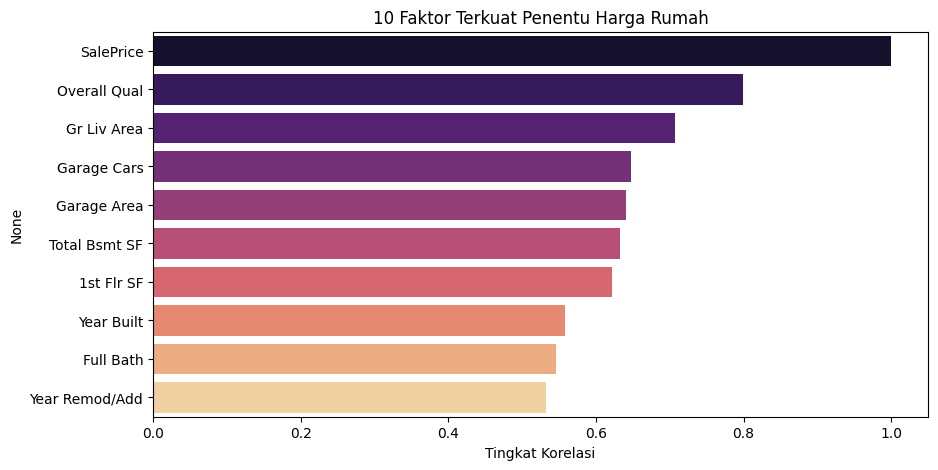

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Memuat data dengan alamat yang sudah benar
df = pd.read_csv('/kaggle/input/datasets/shashanknecrothapa/ames-housing-dataset/AmesHousing.csv')

# 2. Cek dimensi data
print(f"Dataset berhasil dimuat! Dimensi: {df.shape}")

# 3. Mencari fitur angka yang paling berhubungan dengan Harga (SalePrice)
numeric_df = df.select_dtypes(include=['number'])
top_corr = numeric_df.corr()['SalePrice'].sort_values(ascending=False).head(10)

# 4. Visualisasi Faktor Penentu Harga
plt.figure(figsize=(10, 5))
sns.barplot(x=top_corr.values, y=top_corr.index, hue=top_corr.index, palette='magma', legend=False)
plt.title('10 Faktor Terkuat Penentu Harga Rumah')
plt.xlabel('Tingkat Korelasi')
plt.show()


Fitur yang paling panjang (paling atas) adalah faktor yang paling bikin harga rumah naik. Biasanya adalah:

Overall Qual: Kualitas material dan finishing rumah.
Gr Liv Area: Luas lantai di atas tanah.

In [4]:
# Cek kolom yang punya data kosong
missing = df.isnull().sum()
print(missing[missing > 0])

# Isi data kosong pada kolom angka dengan nilai tengah (median)
df['Lot Frontage'] = df['Lot Frontage'].fillna(df['Lot Frontage'].median())
df['Mas Vnr Area'] = df['Mas Vnr Area'].fillna(0)
# (Dan seterusnya untuk kolom penting lainnya)


Lot Frontage       490
Alley             2732
Mas Vnr Type      1775
Mas Vnr Area        23
Bsmt Qual           80
Bsmt Cond           80
Bsmt Exposure       83
BsmtFin Type 1      80
BsmtFin SF 1         1
BsmtFin Type 2      81
BsmtFin SF 2         1
Bsmt Unf SF          1
Total Bsmt SF        1
Electrical           1
Bsmt Full Bath       2
Bsmt Half Bath       2
Fireplace Qu      1422
Garage Type        157
Garage Yr Blt      159
Garage Finish      159
Garage Cars          1
Garage Area          1
Garage Qual        159
Garage Cond        159
Pool QC           2917
Fence             2358
Misc Feature      2824
dtype: int64


In [5]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# Kita pilih 5 fitur terkuat berdasarkan grafik korelasi tadi
features = ['Overall Qual', 'Gr Liv Area', 'Garage Cars', 'Total Bsmt SF', 'Full Bath']
X = df[features].fillna(0) # Fitur
y = df['SalePrice'] # Target harga

# Bagi data: 80% untuk latihan, 20% untuk ujian
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [6]:
# Menampilkan 5 baris pertama dari fitur yang dipilih untuk memastikan data ada
print("Data Fitur (X) siap:")
print(X.head())

print("\nData Target (y) siap:")
print(y.head())


Data Fitur (X) siap:
   Overall Qual  Gr Liv Area  Garage Cars  Total Bsmt SF  Full Bath
0             6         1656          2.0         1080.0          1
1             5          896          1.0          882.0          1
2             6         1329          1.0         1329.0          1
3             7         2110          2.0         2110.0          2
4             5         1629          2.0          928.0          2

Data Target (y) siap:
0    215000
1    105000
2    172000
3    244000
4    189900
Name: SalePrice, dtype: int64


In [7]:
# Inisialisasi model Linear Regression
model_rumah = LinearRegression()

# Latih AI
model_rumah.fit(X_train, y_train)

# AI mencoba menebak harga rumah dari data ujian
y_pred = model_rumah.predict(X_test)

# Cek akurasi
print(f"R2 Score: {r2_score(y_test, y_pred):.2f}")
print(f"Rata-rata error tebakan: ${mean_absolute_error(y_test, y_pred):,.0f}")


R2 Score: 0.79
Rata-rata error tebakan: $26,465


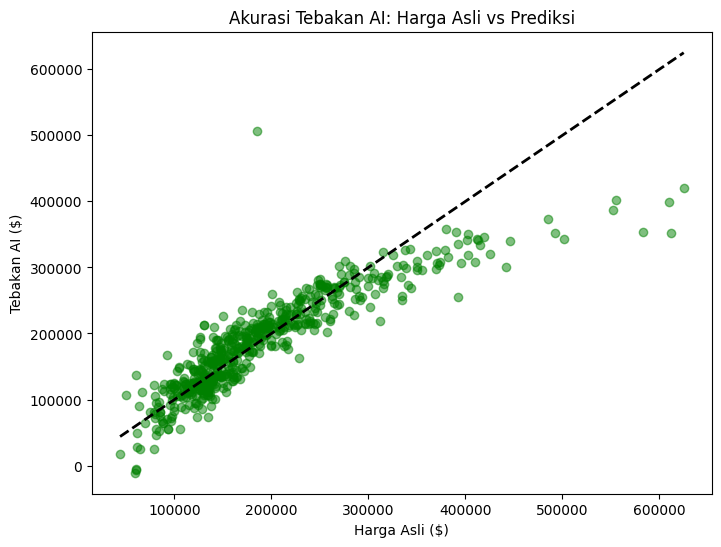

In [8]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.xlabel('Harga Asli ($)')
plt.ylabel('Tebakan AI ($)')
plt.title('Akurasi Tebakan AI: Harga Asli vs Prediksi')
plt.show()
